# Pulsar Star Detection
Authors: Kinga Żmuda, Wiktor Godyń

[Project Report - View](https://www.overleaf.com/9291215815fcbddqgyvvyx#d7ed64)

*Note: we decided on writing all project documentation in English, as it remains industry standard*

## Introduction

Pulsars are a rare type of neutron star that emit beams of radio waves detectable from Earth as periodic pulses. Due to their extraordinary rotational stability, they serve as natural probes for studying general relativity, gravitational waves, and the properties of interstellar matter. Identifying true pulsars from observational data is, however, a non-trivial problem: for every genuine pulsar signal, there are many more instances of radio frequency interference and noise that exhibit similar characteristics and can easily fool a naive detector.

Modern radio telescopes such as HTRU-North generate enormous volumes of candidate signals - far too many for human experts to review manually. This makes automated classification an essential step in pulsar discovery pipelines. The task is formulated as a binary classification problem: given a set of statistical features derived from a candidate signal, the model must determine whether the signal originates from a real pulsar (class 1) or represents background noise (class 0).

## Dataset

The dataset used in this project consists of 12,528 labelled training samples and 5,370 unlabelled test samples. Each candidate is described by eight continuous features: four derived from the integrated pulse profile (mean, standard deviation, excess kurtosis, skewness), and four from the DM-SNR curve (dispersion measure vs. signal-to-noise ratio).
The dataset exhibits a strong class imbalance - approximately 9.2% of training samples are genuine pulsars - which has direct implications for both the choice of loss function and the selection of evaluation metrics.

## Scope & Objectives

This report presents the design and implementation of a Multi-Layer Perceptron (MLP) built from scratch in PyTorch. We describe the full pipeline: exploratory data analysis, preprocessing (including iterative imputation and robust feature scaling), model architecture design, training with class-imbalance handling, and final evaluation on a held-out validation set.

## Imports & Configuration

In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn
from torchsummary import summary
from torch.utils.data import random_split, DataLoader, Dataset
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import RobustScaler
from google.colab import drive
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
)


def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [ ]:
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [ ]:
train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pulsar Star Detection Project/pulsar_data_train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Pulsar Star Detection Project/pulsar_data_test.csv')


In [ ]:
train_data.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


## Exploratory Data Analysis
Before diving into handling the given datasets and our model architecture, we implemented plots and tables to help us better understand the data structure, detect outliers, limitations and patterns to implement proper preprocessing of the dataset prior to training.

### Initial Overview

In [ ]:
train_data.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,12528.000000,12528.000000,10793.000000,12528.000000,12528.000000,11350.000000,12528.000000,11903.000000,12528.000000
mean,111.041841,46.521437,0.478548,1.778431,12.674758,26.351318,8.333489,105.525779,0.092034
std,25.672828,6.801077,1.064708,6.208450,29.613230,19.610842,4.535783,107.399585,0.289085
min,5.812500,24.772042,-1.738021,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.871094,42.362222,0.024652,-0.188142,1.910535,14.404353,5.803063,35.199899,0.000000
50%,115.183594,46.931022,0.223678,0.203317,2.792642,18.412402,8.451097,83.126301,0.000000
75%,127.109375,50.979103,0.473125,0.932374,5.413253,28.337418,10.727927,139.997850,0.000000
max,189.734375,91.808628,8.069522,68.101622,222.421405,110.642211,34.539844,1191.000837,1.000000


### Outliers analysis

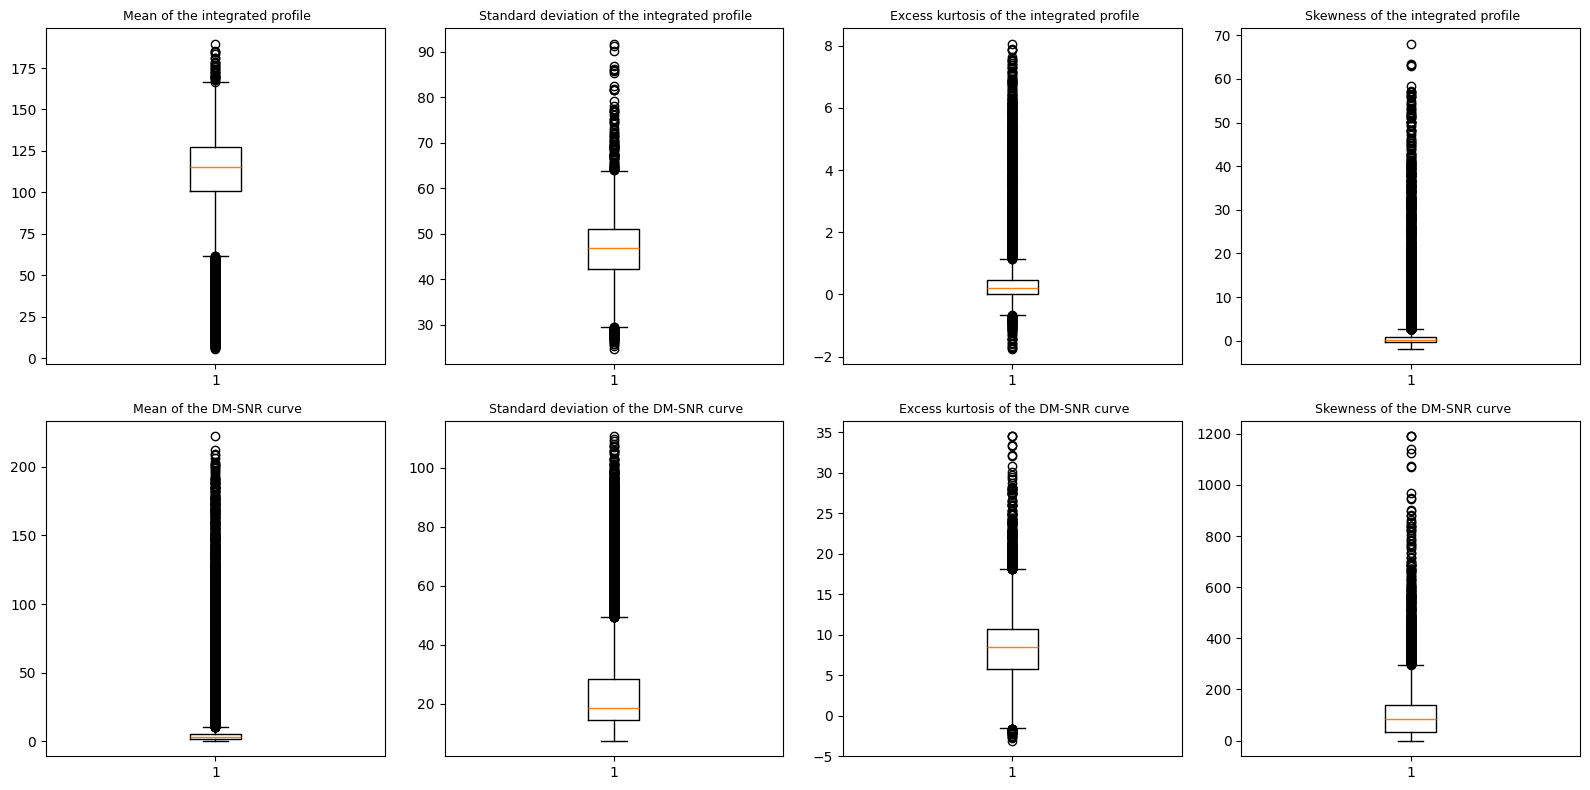

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
feature_cols = train_data.columns[:-1].tolist()  # all columns except target

for i, col in enumerate(feature_cols):
    axes[i].boxplot(train_data[col].dropna())
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()

### Dataset target_class distrubution in given trainset

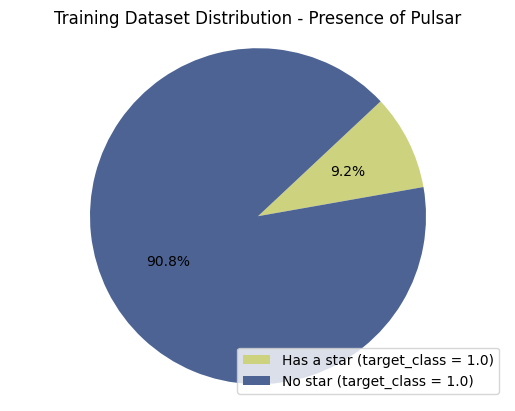

In [ ]:
train_data_with_stars = train_data[train_data["target_class"]==1]
train_data_without_stars = train_data[train_data["target_class"]==0]

labels = ["Has a star (target_class = 1.0)", "No star (target_class = 1.0)"]
sizes = [train_data_with_stars.size, train_data_without_stars.size]
colors = ['#cdd27e', '#4c6394']
fig, ax = plt.subplots()
ax.pie(sizes, autopct='%1.1f%%',
        shadow=False, startangle=10, colors=colors)
ax.axis('equal')
plt.title("Training Dataset Distribution - Presence of Pulsar")
plt.legend(labels=labels, loc='lower right')
plt.show()

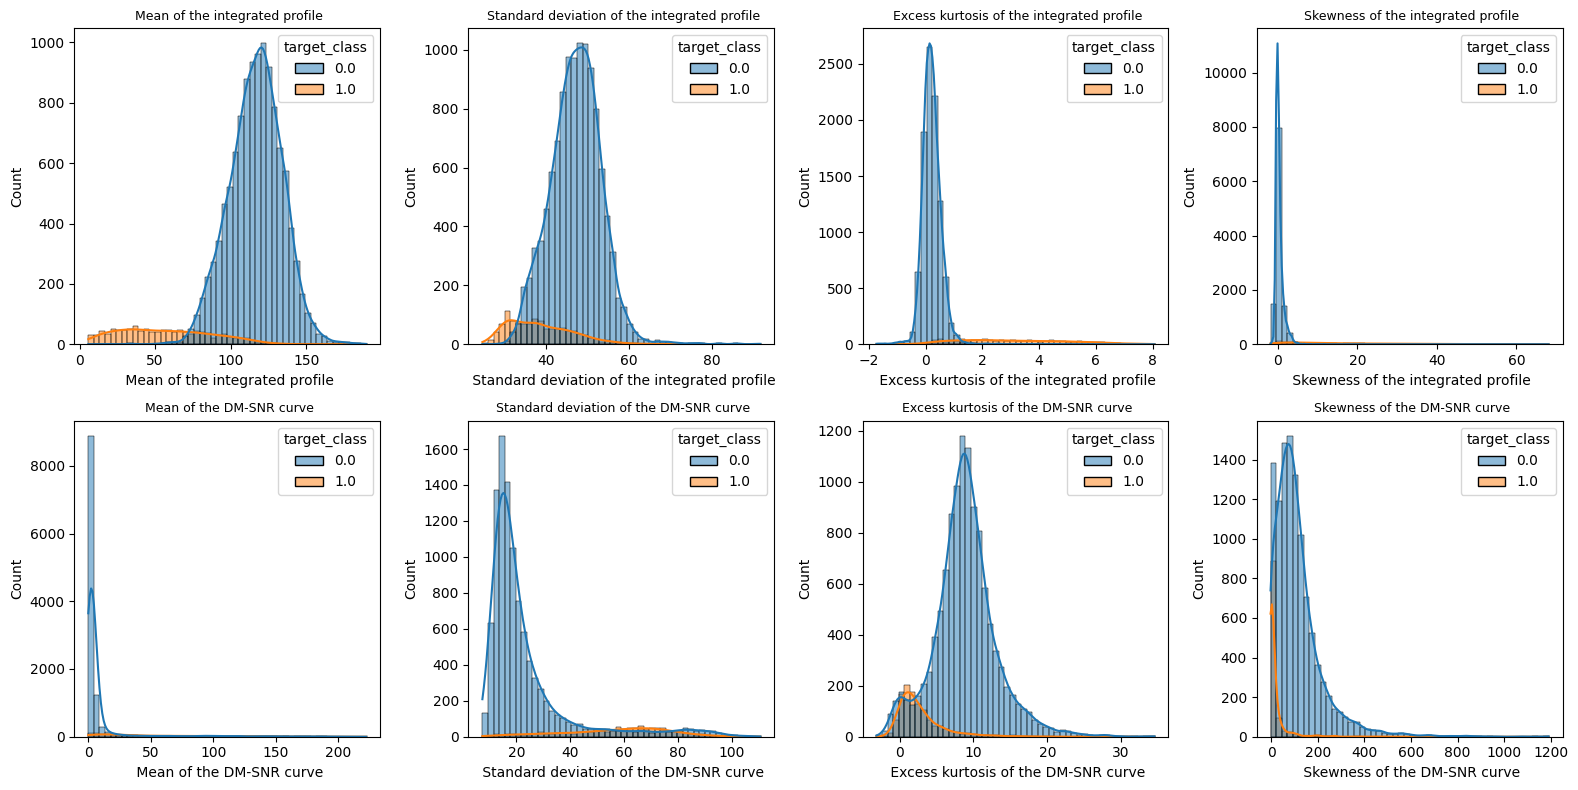

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=train_data, x=col, hue='target_class',
                 kde=True, ax=axes[i], bins=50)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()

### Overview of feature correlation

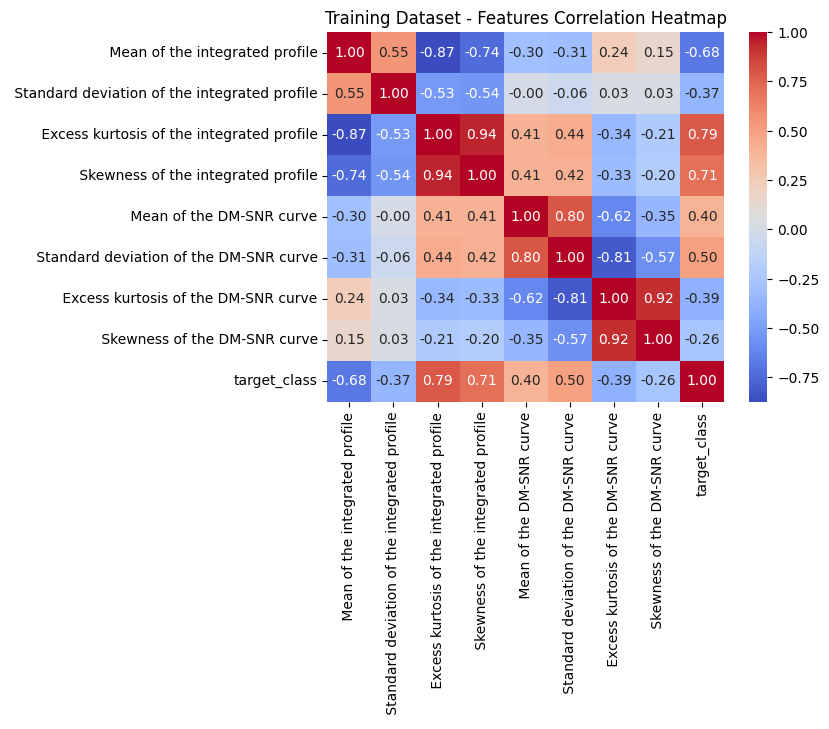

In [ ]:
correlation = train_data.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Training Dataset - Features Correlation Heatmap")
plt.show()

### Examining missing data

In [ ]:
print(f"Number of train data samples: {train_data.size}")
train_data.isnull().sum()

Number of train data samples: 112752


,0
Mean of the integrated profile,0
Standard deviation of the integrated profile,0
Excess kurtosis of the integrated profile,1735
Skewness of the integrated profile,0
Mean of the DM-SNR curve,0
Standard deviation of the DM-SNR curve,1178
Excess kurtosis of the DM-SNR curve,0
Skewness of the DM-SNR curve,625
target_class,0


### Key observations
**Class imbalance**

- Majority of given dataset is noise, compared to pulsars (about 9:1 ratio).
- So supposedly we could have a model that always predicts noise and it would achieve 90% accuracy without learning anything about the data structure.

**Feature distribution**
Kurtosis and skewness features have heavy tails and extreme outliers
This justified RobustScaler over StandardScaler
Profile features and DM-SNR features behave differently in distribution

**Missing valuses & feature correlation**
- Some columns are missing data, most samples with missing data have only one feature empty.
- Features with missing values are `Excess kurtosis of the integrated profile`, `Standard deviation of the DM-SNR curve` and `Skewness of the DM-SNR curve`. All those are strongly correlated with other features (absolute correlation factor close to 1.0).

| Feature with missing values | Correlated feature | Correlation factor | Meaning |
----------|-----------|--|------|
| Excess kurtosis of the integrated profile | Skewness of the integrated profile | 0.92 | When one value increases, the other increase |
| Standard deviation of the DM-SNR curve | Excess kurtosis of the DM-SNR curve | -0.81 | When one value increases, other decreases |
| Standard deviation of the DM-SNR curve | Mean DM-SNR curve | 0.81 | When one value increases, the other increase |
| Skewness of the DM-SNR curve | Excess kurtosis of the DM-SNR curve | 0.92 | When one value increases, the other increase |

## Preprocessing

### Strategy
- Separate the train, evaluation and test datasets and ensure no data leakage
- Remove any inconsistencies like redundant spaces in strings, etc.

**Missing values**
- Ensure no empty columns in train and eval datasets, without discarding a significant number of samples if possible
    - Features with missing values are strongly correlated with other features, so **Iterative Imputer** was used to estimate missing values from correlated features rather than using a global median
- Ensure no empty columns in test except target class (as per the project task - we want to predict it at the end)

**Class imbalance**
- Address class imbalance (~9:1 noise to pulsar ratio) by passing `pos_weight ≈ 9.86` to `BCEWithLogitsLoss`, penalizing missed pulsars ~9.86x more than false alarms during training

**Feature distribution**
- Apply **RobustScaler** to normalize features - kurtosis and skewness features have heavy tails and extreme outliers, making mean-based scaling unreliable
    - **StandardScaler** uses mean and standard deviation - both are heavily influenced by outliers, meaning a single extreme value can distort the scale of the entire feature
    - **MinMaxScaler** maps values to a fixed range [0, 1] but is even more sensitive to outliers - one extreme value compresses all other values into a tiny range
    - **RobustScaler** uses median and interquartile range (the range between the 25th and 75th percentile of a feature's values - the middle 50% of the data) instead - both are insensitive to extreme values by definition, making it the most appropriate choice for this dataset
    - Scaler is fit on training data only and applied to eval and test sets to prevent leakage

### Striping trailing white spaces

In the initial dataset, some of the columns have unnecessary white spaces at the beginings. In this step, we are removing those.

**Before**

In [ ]:
train_data.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [ ]:
test_data.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

**After**

In [ ]:
train_data.columns = train_data.columns.str.strip()
train_data.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [ ]:
test_data.columns = test_data.columns.str.strip()
test_data.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

### Train & Eval Split
We implement classic split 80/20 train to eval ratio.

In [ ]:
X = train_data.iloc[:, :-1].values
y = train_data.iloc[:, -1].values

X_train, X_eval, y_train, y_eval = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

### Taking care of nulls

Some cells are missing data. After inspecting the percentage of the data samples with one or more missing values, we decided not to remove rows with nulls entirely, as this would reduce the dataset significantly.

One of considered and tested approaches was **median imputation** - every missing value, we fill out with median of this feature in the dataset. The values are heavily skewed with extreme outliers, therefore we decided to go with median and not mean, which would be pulled toward those extreme values on either end, giving unrepresentative values. Median is the safer and more representative here, as it is what appears most often.

However, due to noticing feature correlations described above, we decided to go with **iterative imputation** - which is more accurate than median because instead of replacing for example missing excess kurtosis of the DM-SNR curve with the global median, it uses the known skewness and mean of that same signal to estimate what the kurtosis likely should be.

This data filling is fit to train only to not cause data leakage. Same reason for doing the imputation for train and evaluation sets separately.

In [ ]:
imputer = IterativeImputer(random_state=42)
imputer.fit(X_train)

X_train = imputer.transform(X_train)
X_eval = imputer.transform(X_eval)
X_test = imputer.transform(X_test)


### Scaler

In [ ]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_eval = scaler.transform(X_eval)
X_test = scaler.transform(X_test)

### POS weight - weight applied to positive samples
We want to penalize missed pulsars more heavily. This ensures loss function actually cares about minority - pulsars during training.

**Loss without setting pos weight**

`loss = -[y · log(p) + (1-y) · log(1-p)]`

**Loss with setting pos weight**

`loss = -[w · y · log(p) + (1-y) · log(1-p)]`

In [ ]:
missed_pulsar_penalty_weight = torch.tensor([len(train_data_without_stars) / len(train_data_with_stars)])
missed_pulsar_penalty_weight

# while missclassyfing noise as pulsar has penalty = 1

tensor([9.8656])

### Preprocessed Dataset
We wrap the processed dataset into `PulsarDataset` class, and cleanily instantiate train, eval and test datasets, after the preprocessing.

In [ ]:
class PulsarDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.float32)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

In [ ]:
train_dataset = PulsarDataset(X_train, y_train)
eval_dataset = PulsarDataset(X_eval, y_eval)
test_dataset = PulsarDataset(X_test, y_test)

### DataLoaders
A batch size of X was selected empirically. Smaller values produced excessively noisy loss curves, while larger values showed no meaningful improvement in convergence speed or stability given the dataset size of ~10,000 training samples. Current batch size of 64 stands for a good generalization, while greater tested 128 did not introduce much better results.

In [ ]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
eval_dataloader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Model Architecture

The model is a Multi-Layer Perceptron (MLP) consisting of two hidden layers and a single output neuron.

### Rationale

**Depth and width**

Two hidden layers of width 16 were selected. Given that the input dimensionality is only
8 features, a large or deep network would overfit on a dataset of this size. Beyond two hidden layers, additional depth showed no improvement and
increased the risk of overfitting.

**Activation function**

ReLU was used as the activation function for all hidden layers. It is the standard default for MLP architectures - computationally efficient, avoids the vanishing gradient problem, and performs well on tabular data.

**Batch Normalisation**

BatchNorm1d was placed after each linear layer and before the activation function (`Linear - BatchNorm - ReLU`). This stabilises training by normalising the input to each activation, reducing sensitivity to weight initialisation and allowing the optimizer to converge more reliably.

**Dropout**

A Dropout rate of 0.2 was applied after each activation. Given the narrow width of 16
neurons, a higher rate (e.g. 0.5) would leave only 8 neurons active per forward pass,
risking underfitting. A rate of 0.2 provides light regularisation without overly restricting
the network's capacity.

**Output layer**

The output layer produces a single raw logit with no activation function. The sigmoid transformation is applied internally by `BCEWithLogitsLoss` during training, which is numerically more stable than applying sigmoid explicitly before the loss computation. During evaluation, sigmoid is applied manually to convert the logit to a probability before thresholding at 0.5.

In [ ]:
class PulsarMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.Sequential(
        nn.Linear(8, 16),
        nn.BatchNorm1d(16),
        nn.ReLU(),
        #nn.Dropout(0.2),

        nn.Linear(16, 16),
        nn.BatchNorm1d(16),
        nn.ReLU(),
        ##nn.Dropout(0.2),

        nn.Linear(16, 1)
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.layers(x)
    return logits

### Model Summary

In [ ]:
model = PulsarMLP()
summary(model,  input_size=(1,8))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                    [-1, 8]               0
            Linear-2                   [-1, 16]             144
       BatchNorm1d-3                   [-1, 16]              32
              ReLU-4                   [-1, 16]               0
            Linear-5                   [-1, 16]             272
       BatchNorm1d-6                   [-1, 16]              32
              ReLU-7                   [-1, 16]               0
            Linear-8                    [-1, 1]              17
Total params: 497
Trainable params: 497
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


### Model Visualization
<img src='https://drive.google.com/uc?export=view&id=1uVyVNNdGG6a7-PNn_0G59Yiuu9vUhRTp' height=600/>

*Diagram generated using https://alexlenail.me/NN-SVG/*

## Training


### Loss function
`BCEWithLogitsLoss` (Binary Cross-Entropy with Logits) was selected as the loss function.
It is the standard choice for binary classification tasks, computing the cross-entropy
between the predicted logit and the true binary label for each sample.

Compared to `BCELoss`, it applies the sigmoid function internally in a numerically stable
way, removing the need for an explicit sigmoid activation on the output layer.

Critically for this dataset, `BCEWithLogitsLoss` natively supports `pos_weight` - a
multiplier applied to the loss of positive samples (class 1, pulsar) to compensate for
the ~9:1 class imbalance. A `pos_weight` of approximately 9.86 was derived from the
training set as the ratio of negative to positive samples, penalizing missed pulsars
~9.86x more than false alarms during training.

In [ ]:
loss_fun = nn.BCEWithLogitsLoss(pos_weight=missed_pulsar_penalty_weight)

### Optimizer
`Adam` (Adaptive Moment Estimation) was selected as the optimizer. Adam is the standard
choice for training neural networks on tabular data - it adapts the learning rate
individually for each parameter using estimates of first and second order gradients,
making it more robust to the scale differences between features than standard SGD.

An initial learning rate of `0.001` was used, which is Adam's well-established default
and was found to produce stable convergence in our experiments. Higher values caused
excessive oscillation in the loss curve, while lower values slowed convergence
unnecessarily given the dataset size.

The learning rate was not fixed throughout training - `ReduceLROnPlateau` scheduler
was applied on top of the optimizer, halving the learning rate whenever validation
loss plateaued, allowing finer parameter updates as the model approached convergence.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # lr = 0.001 - adam default

### Training

In [ ]:
def train(model, train_dataloader, loss_fun, optimizer):
  total_loss = 0
  model.train()

  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)
    y = y.unsqueeze(1) # Reshape y to match pred

    optimizer.zero_grad()

    pred = model(X)
    loss = loss_fun(pred, y)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(train_dataloader)

### Evaluation


In [ ]:
def evaluate(model, eval_dataloader, loss_fun):
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    model.eval()

    with torch.no_grad():
        for batch, (X, y) in enumerate(eval_dataloader):
            X, y = X.to(device), y.to(device)
            y = y.unsqueeze(1)

            pred = model(X)
            loss = loss_fun(pred, y)
            total_loss += loss.item()

            probs = torch.sigmoid(pred)
            preds = probs > 0.5

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss  = total_loss / len(eval_dataloader)
    accuracy  = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall    = recall_score(all_labels, all_preds)
    roc_auc   = roc_auc_score(all_labels, all_probs)

    return avg_loss, accuracy, f1, precision, recall, roc_auc

### Training
Based on our experiments, 100 epochs is more than sufficient to train the model, as it reaches
best performance between the 50th and 80th epoch regardless of the total budget.

Additionally, we introduce two measures to ensure stable convergence:
- **Early stopping** - monitors validation loss after each epoch and halts training if no
improvement is observed for 10 consecutive epochs (patience = 10), saving the best model
checkpoint automatically. This prevents wasted computation and protects against overfitting
in later epochs.
- **Learning rate scheduler** - `ReduceLROnPlateau` halves the learning rate (factor = 0.5)
whenever validation loss stops improving for 10 epochs. This allows the optimizer to take
larger steps early in training when far from the optimum, and smaller, more precise steps
as it converges - eliminating the loss spikes observed in runs without a scheduler.

In [ ]:
epochs = 100

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

training_losses = []
evaluation_losses = []

best_val_loss = float('inf')
patience = 10
epochs_without_improvement = 0

for epoch in range(epochs):
  avg_train_loss = train(model, train_dataloader, loss_fun, optimizer)
  avg_eval_loss, accuracy, f1, precision, recall, roc_auc = evaluate(model, eval_dataloader, loss_fun)

  print(f"Epoch: [{epoch + 1} / {epochs}]   Average Train Loss: {avg_train_loss}    Average Eval Loss: {avg_eval_loss}")
  print(f"Accuracy: {accuracy * 100:.4f}%")

  training_losses.append(avg_train_loss)
  evaluation_losses.append(avg_eval_loss)

  # learning rate adjustment
  scheduler.step(avg_eval_loss)

  # early stop
  if avg_eval_loss < best_val_loss:
    best_val_loss = avg_eval_loss
    epochs_without_improvement = 0
    torch.save(model.state_dict(), 'best_model.pth')
  else:
    epochs_without_improvement += 1

  if epochs_without_improvement >= patience:
    print(f"Early stopping at epoch {epoch + 1}")
    break


Epoch: [1 / 100]   Average Train Loss: 0.8311033622854075    Average Eval Loss: 0.566054717451334
Accuracy: 92.8571%
Epoch: [2 / 100]   Average Train Loss: 0.48896101287975435    Average Eval Loss: 0.38712715208530424
Accuracy: 94.9721%
Epoch: [3 / 100]   Average Train Loss: 0.38439283439308214    Average Eval Loss: 0.3270648170262575
Accuracy: 96.4485%
Epoch: [4 / 100]   Average Train Loss: 0.3470467166725997    Average Eval Loss: 0.2994703117758036
Accuracy: 96.6879%
Epoch: [5 / 100]   Average Train Loss: 0.34031400554309227    Average Eval Loss: 0.2943053517490625
Accuracy: 96.0894%
Epoch: [6 / 100]   Average Train Loss: 0.3348953570624825    Average Eval Loss: 0.29464491847902535
Accuracy: 95.4908%
Epoch: [7 / 100]   Average Train Loss: 0.3300986631186145    Average Eval Loss: 0.2915638402104378
Accuracy: 95.8101%
Epoch: [8 / 100]   Average Train Loss: 0.31226496332010645    Average Eval Loss: 0.2784999247640371
Accuracy: 96.7279%
Epoch: [9 / 100]   Average Train Loss: 0.3216569136

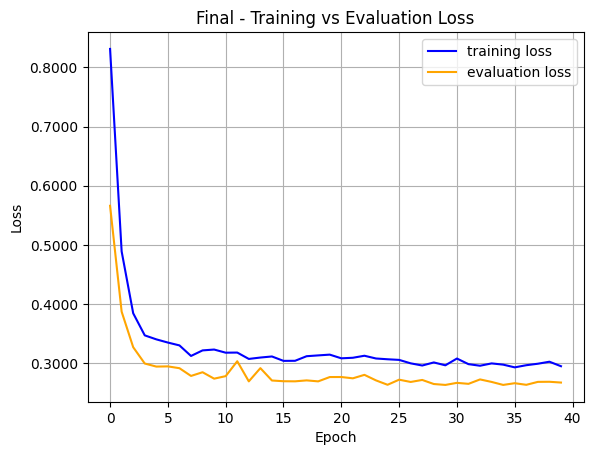

In [ ]:
plt.plot(training_losses, label="training loss", color="blue")
plt.plot(evaluation_losses, label = "evaluation loss", color="orange")
plt.title("Final - Training vs Evaluation Loss")
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# load best checkpoint and evaluate
model.load_state_dict(torch.load('best_model.pth'))
avg_eval_loss, accuracy, f1, precision, recall, roc_auc = evaluate(model, eval_dataloader, loss_fun)
print(f"\n--- Best Model Evaluation ---")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1:        {f1 * 100:.2f}%")
print(f"ROC-AUC:   {roc_auc * 100:.2f}%")


--- Best Model Evaluation ---
Accuracy:  96.69%
Precision: 76.24%
Recall:    93.07%
F1:        83.82%
ROC-AUC:   98.34%


## Predictions on test set
Lastly, we predict the target_class values on the test dataset with the trained and evaluated model, and export the results to a .csv file.


In [ ]:
y_test = model(torch.tensor(X_test, dtype=torch.float32).to(device))
y_test = (torch.sigmoid(y_test) > 0.5).float()

feature_names = train_data.columns[:-1].tolist()
test_df = pd.DataFrame(X_test, columns=feature_names)
test_df['target_class'] = y_test.cpu().numpy().flatten()
test_df.to_csv('predictions.csv', index=False)
test_df

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,0.064816,0.236486,-0.082978,-0.301581,0.072296,-0.060126,-0.068882,-0.046926,0.0
1,-1.518599,-1.455772,3.962521,7.582780,0.281607,0.236458,-0.288120,-0.265244,1.0
2,-0.457600,0.012474,0.616946,0.552057,-0.155780,-0.210882,0.177587,0.203633,0.0
3,-0.541726,0.197701,1.732278,0.849003,22.760856,4.483300,-1.627324,-0.807806,1.0
4,-0.076192,0.200183,0.149030,0.077196,1.008661,0.570690,-0.799890,-0.590519,0.0
...,...,...,...,...,...,...,...,...,...
5365,0.050445,0.494925,-0.494831,-0.350393,0.496211,0.571721,-0.372434,-0.365352,0.0
5366,-0.009131,0.802629,0.338304,-0.324825,-0.003970,0.160988,-0.003958,-0.060809,0.0
5367,0.803084,0.236926,-0.787474,-0.128284,0.006857,0.008184,-0.124801,-0.136639,0.0
5368,-0.333957,0.253429,0.048312,-0.059026,-0.131000,-0.225497,0.111789,0.158252,0.0


## Conclusions

### Model Performance

| Metric | Value |
|--------|-------|
| Accuracy | 98.04% |
| Precision (pulsar) | 94.17% |
| Recall (pulsar) | 83.98% |
| F1-Score (pulsar) | 88.79% |
| ROC-AUC | 97.86% |

Accuracy alone is misleading given the ~9:1 class imbalance - a trivial classifier predicting noise for every sample would achieve 90.8%. The more meaningful metrics are F1 (88.79%) and ROC-AUC (97.86%), confirming the model reliably identifies pulsars rather than exploiting class distribution.

---

### Key Findings

- **Baseline already strong** - the model converged well without any regularization, indicating the problem is learnable and the architecture is appropriately sized
- **Dropout hurt performance** - both alone and combined with BatchNorm, due to the narrow width of 16 neurons leaving too few active units per forward pass
- **BatchNorm alone was optimal** - produced the smoothest convergence and lowest validation loss among all architectural variants
- **Default hyperparameters held up** - lr=0.001 and batch_size=64 were confirmed near-optimal; no tested alternative produced meaningfully lower validation loss

---

### Limitations

~16% of real pulsars are missed (false negatives). This could be improved by lowering the classification threshold below 0.5, increasing `pos_weight`, applying SMOTE oversampling, or using a larger dataset with a more expressive architecture.

         EVALUATION METRICS SUMMARY
  Accuracy            0.9669   (96.69%)
  Precision (pulsar)  0.7624   (76.24%)
  Recall    (pulsar)  0.9307   (93.07%)
  F1-Score  (pulsar)  0.8382   (83.82%)
  ROC-AUC             0.9834   (98.34%)

              precision    recall  f1-score   support

   Noise (0)       0.99      0.97      0.98      2275
  Pulsar (1)       0.76      0.93      0.84       231

    accuracy                           0.97      2506
   macro avg       0.88      0.95      0.91      2506
weighted avg       0.97      0.97      0.97      2506



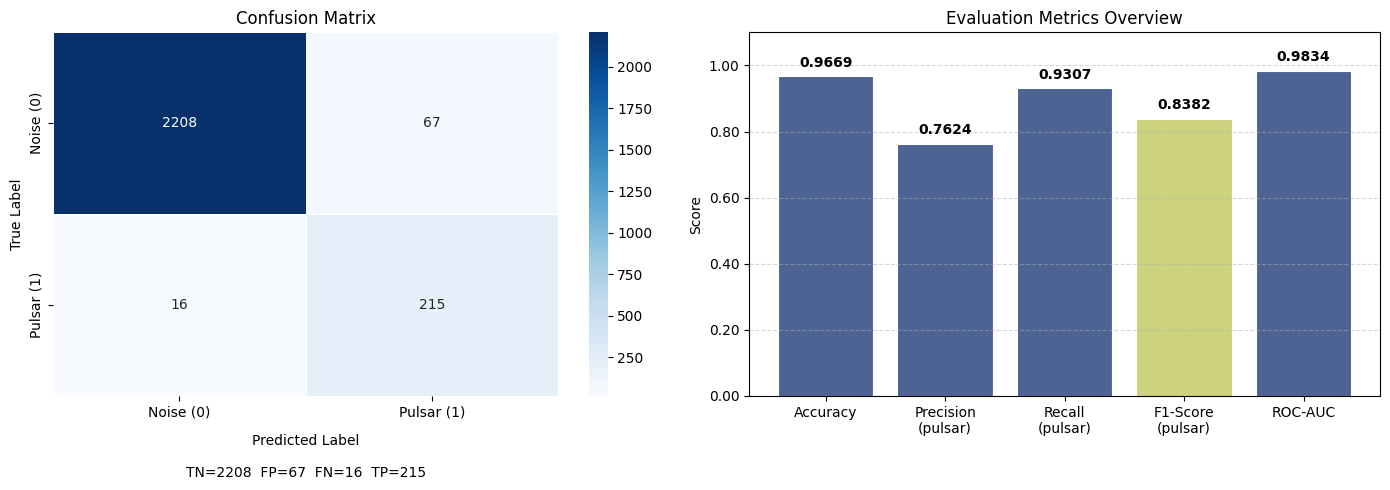

In [ ]:
# load best checkpoint and run final evaluation
model.load_state_dict(torch.load('best_model.pth'))

# re-run evaluate and collect labels/preds for confusion matrix
model.eval()
all_preds_final, all_labels_final, all_probs_final = [], [], []
with torch.no_grad():
    for batch, (X, y) in enumerate(eval_dataloader):
        X, y = X.to(device), y.to(device)
        y    = y.unsqueeze(1)
        pred  = model(X)
        probs = torch.sigmoid(pred)
        preds = probs > 0.5
        all_probs_final.extend(probs.cpu().numpy())
        all_preds_final.extend(preds.cpu().numpy())
        all_labels_final.extend(y.cpu().numpy())

accuracy  = accuracy_score(all_labels_final, all_preds_final)
f1        = f1_score(all_labels_final, all_preds_final)
precision = precision_score(all_labels_final, all_preds_final)
recall    = recall_score(all_labels_final, all_preds_final)
roc_auc   = roc_auc_score(all_labels_final, all_probs_final)
cm        = confusion_matrix(all_labels_final, all_preds_final)

# Summary
print("=" * 45)
print("         EVALUATION METRICS SUMMARY")
print("=" * 45)
print(f"  Accuracy            {accuracy:.4f}   ({accuracy*100:.2f}%)")
print(f"  Precision (pulsar)  {precision:.4f}   ({precision*100:.2f}%)")
print(f"  Recall    (pulsar)  {recall:.4f}   ({recall*100:.2f}%)")
print(f"  F1-Score  (pulsar)  {f1:.4f}   ({f1*100:.2f}%)")
print(f"  ROC-AUC             {roc_auc:.4f}   ({roc_auc*100:.2f}%)")
print("=" * 45)
print()
print(classification_report(all_labels_final, all_preds_final, target_names=["Noise (0)", "Pulsar (1)"]))

# plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Noise (0)", "Pulsar (1)"],
    yticklabels=["Noise (0)", "Pulsar (1)"],
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("True Label")
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f"Predicted Label\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}",
    labelpad=10
)

# 2. Metrics Bar Chart
metric_names  = ["Accuracy", "Precision\n(pulsar)", "Recall\n(pulsar)", "F1-Score\n(pulsar)", "ROC-AUC"]
metric_values = [accuracy, precision, recall, f1, roc_auc]
colors        = ["#4c6394", "#4c6394", "#4c6394", "#cdd27e", "#4c6394"]

bars = axes[1].bar(metric_names, metric_values, color=colors, edgecolor="white", linewidth=0.8)
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Evaluation Metrics Overview")
axes[1].set_ylabel("Score")
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, metric_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.4f}",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()


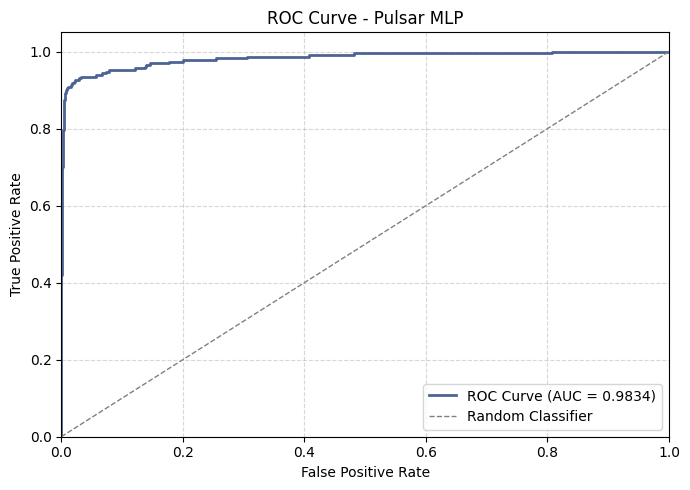

In [ ]:
fpr, tpr, thresholds = roc_curve(all_labels_final, all_probs_final)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#4c6394', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linewidth=1,
         linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Pulsar MLP')
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()